# Logistic Regression

## Import libraries

In [2]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Create simple dataset

In [3]:
data = {
    "Age": [22, 38, 26, 35, 28, 50, 16, 40],
    "Sex": [0, 1, 1, 1, 0, 1, 0, 1],  # 1 = female, 0 = male
    "Pclass": [3, 1, 3, 1, 3, 1, 3, 1],
    "Survived": [0, 1, 1, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,Age,Sex,Pclass,Survived
0,22,0,3,0
1,38,1,1,1
2,26,1,3,1
3,35,1,1,1
4,28,0,3,0
5,50,1,1,1
6,16,0,3,1
7,40,1,1,1


## Select feature and label

In [4]:
X = df[['Age', 'Sex', 'Pclass']]
y= df['Survived']


## Train-Test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## Create & train the model

In [6]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Predict

In [7]:
y_pred = model.predict(X_test)
y_pred

array([1, 1])

## Measure accuracy

In [8]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

1.0

# With Titanic dataset

In [9]:
import seaborn as sns
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.shape, df.dtypes

((891, 15),
 survived          int64
 pclass            int64
 sex              object
 age             float64
 sibsp             int64
 parch             int64
 fare            float64
 embarked         object
 class          category
 who              object
 adult_male         bool
 deck           category
 embark_town      object
 alive            object
 alone              bool
 dtype: object)

## Basic Cleaning

In [11]:
df = df[['survived','pclass','sex','age','fare']]
df= df.dropna()
df

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
885,0,3,female,39.0,29.1250
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
889,1,1,male,26.0,30.0000


In [12]:
df['sex']=df['sex'].map({'male':0, 'female':1})
df

,survived,pclass,sex,age,fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500
...,...,...,...,...,...
885,0,3,1,39.0,29.1250
886,0,2,0,27.0,13.0000
887,1,1,1,19.0,30.0000
889,1,1,0,26.0,30.0000


## Prepare X and y

In [13]:
X = df[['pclass', 'sex', 'age' , 'fare']]
y= df['survived']

## Train_test split

In [14]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

## Train Logistic Regression

In [15]:
model= LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Evaluate Model

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)
print(y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 1 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0 0 0 0 1 0
 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1]
Accuracy: 0.7552447552447552
[[68 19]
 [16 40]]
              precision    recall  f1-score   support

           0       0.81      0.78      0.80        87
           1       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



## ROC curve

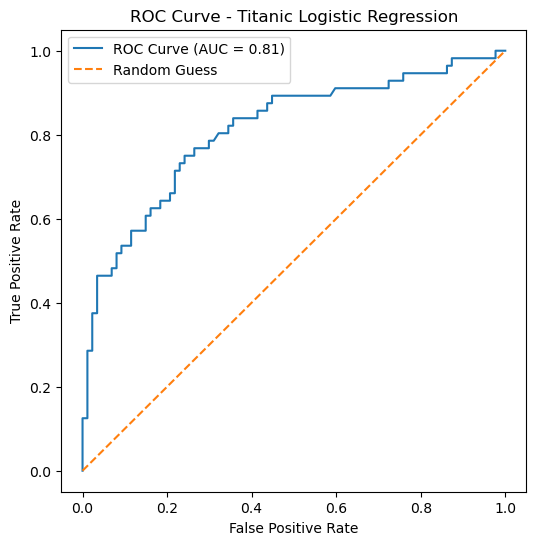

In [17]:
# 1. Import
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 2. Get predicted probabilities for class 1 (Survived = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# 3. Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 4. Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Titanic Logistic Regression")
plt.legend()
plt.show()
